## Crop Yield Prediction  

**Importing libraries**

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

### Import dataset

In [44]:
os.getcwd()

'c:\\Users\\levie\\Desktop\\Desktop\\CMU\\Academic Bootcamp\\YieldSense-Crop-Yield-Forecasting-Carnegie-Mellon-University\\data\\raw'

In [45]:
crop = pd.read_csv("crop_prediction_gee_computations.csv")
print(crop.head())

      GNDVI      NDVI      NDWI      SAVI crop_type date_of_image field_id  \
0  0.084801  0.060190 -0.084801  0.090280      Rice    01-01-2023  Field_1   
1  0.222009  0.213957 -0.222009  0.320896      Rice    16-01-2023  Field_1   
2  0.431204  0.403306 -0.431204  0.604837      Rice    31-01-2023  Field_1   
3  0.444132  0.418187 -0.444132  0.627144      Rice    15-02-2023  Field_1   
4  0.387985  0.375138 -0.387985  0.562591      Rice    03-02-2023  Field_1   

   gee_gndvi  gee_ndvi  gee_ndwi  gee_rainfall  gee_savi   gee_temp  \
0   0.295214  0.330551 -0.295214      1.261195  0.176135  19.472947   
1   0.426134  0.410556 -0.426134      2.446377  0.197592  19.497637   
2   0.406732  0.399812 -0.406732      3.722453  0.201092  21.559492   
3   0.426134  0.410556 -0.426134      2.314044  0.197592  19.230342   
4   0.426134  0.410556 -0.426134      1.325544  0.197592  18.863504   

    rainfall  soil_moisture  temperature      yield  
0   1.662354      46.119353     9.884229  40.21803

### Selecting required columns

In [46]:
crop_gee = crop.drop(["GNDVI","NDVI","NDWI","SAVI","date_of_image","field_id","rainfall","temperature"], axis = 1)
crop_gee.head()

,crop_type,gee_gndvi,gee_ndvi,gee_ndwi,gee_rainfall,gee_savi,gee_temp,soil_moisture,yield
0,Rice,0.295214,0.330551,-0.295214,1.261195,0.176135,19.472947,46.119353,40.218031
1,Rice,0.426134,0.410556,-0.426134,2.446377,0.197592,19.497637,37.542525,30.870338
2,Rice,0.406732,0.399812,-0.406732,3.722453,0.201092,21.559492,24.926279,45.330050
3,Rice,0.426134,0.410556,-0.426134,2.314044,0.197592,19.230342,24.114157,49.711781
4,Rice,0.426134,0.410556,-0.426134,1.325544,0.197592,18.863504,27.420927,34.542646


In [47]:
#Checking the shape of the dataset
print(crop_gee.shape)

(1625, 9)


In [48]:
crop_gee.info()

<class 'pandas.DataFrame'>
RangeIndex: 1625 entries, 0 to 1624
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   crop_type      1625 non-null   str    
 1   gee_gndvi      1625 non-null   float64
 2   gee_ndvi       1625 non-null   float64
 3   gee_ndwi       1625 non-null   float64
 4   gee_rainfall   1599 non-null   float64
 5   gee_savi       1625 non-null   float64
 6   gee_temp       1530 non-null   float64
 7   soil_moisture  1625 non-null   float64
 8   yield          1625 non-null   float64
dtypes: float64(8), str(1)
memory usage: 114.4 KB


In [49]:
#Checking for null values
print(crop_gee.isnull().sum())

crop_type         0
gee_gndvi         0
gee_ndvi          0
gee_ndwi          0
gee_rainfall     26
gee_savi          0
gee_temp         95
soil_moisture     0
yield             0
dtype: int64


In [50]:
# Filling the rainfall and temperature column with the median
imputer = SimpleImputer(strategy= "median")
cols_to_impute = ["gee_rainfall", "gee_temp"]

crop_gee[cols_to_impute] = imputer.fit_transform(crop_gee[cols_to_impute])

print(f"All columns sorted, no NA values: {crop_gee.isnull().sum()}")

All columns sorted, no NA values: crop_type        0
gee_gndvi        0
gee_ndvi         0
gee_ndwi         0
gee_rainfall     0
gee_savi         0
gee_temp         0
soil_moisture    0
yield            0
dtype: int64


In [51]:
#Checking for duplicates
print(crop_gee.duplicated().sum())

0


### Exploratory Data Analysis

In [52]:
sns.set_style("whitegrid")

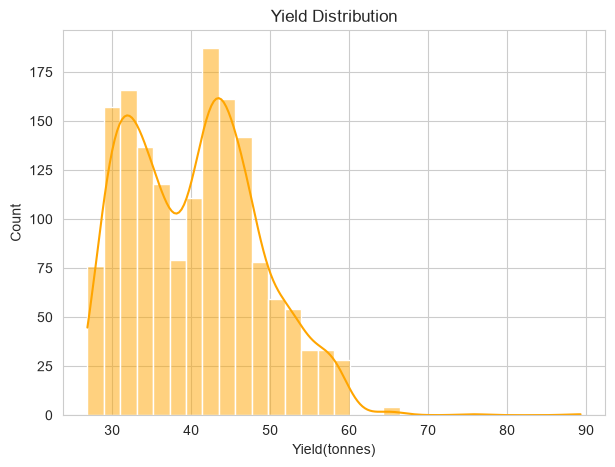

In [53]:
plt.figure(figsize = (7,5))
sns.histplot(crop_gee["yield"], bins= 30, kde = True, color= "orange")
plt.xlabel("Yield(tonnes)")
plt.title("Yield Distribution")
plt.show()

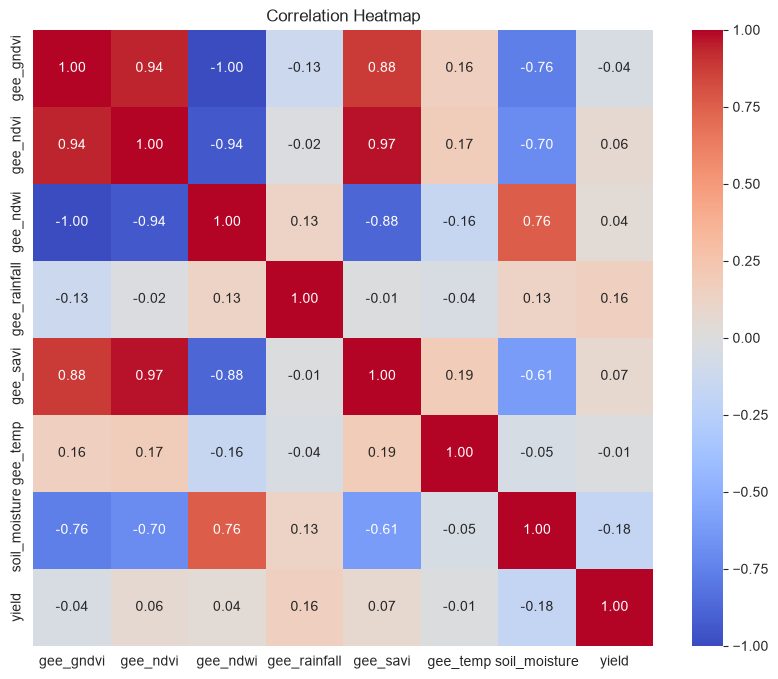

In [54]:
plt.figure(figsize= (10,8))

corr_matrix = crop_gee.select_dtypes(include = ["float64"]).corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

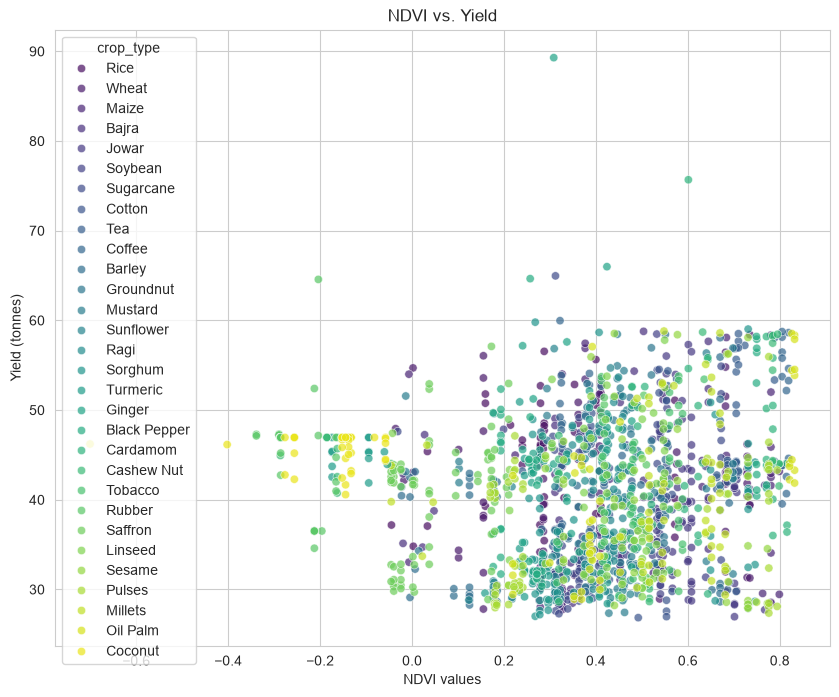

In [55]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=crop_gee, x="gee_ndvi", y="yield", hue="crop_type", palette="viridis", alpha=0.7)
plt.xlabel("NDVI values")
plt.ylabel("Yield (tonnes)")
plt.title("NDVI vs. Yield")
plt.show()

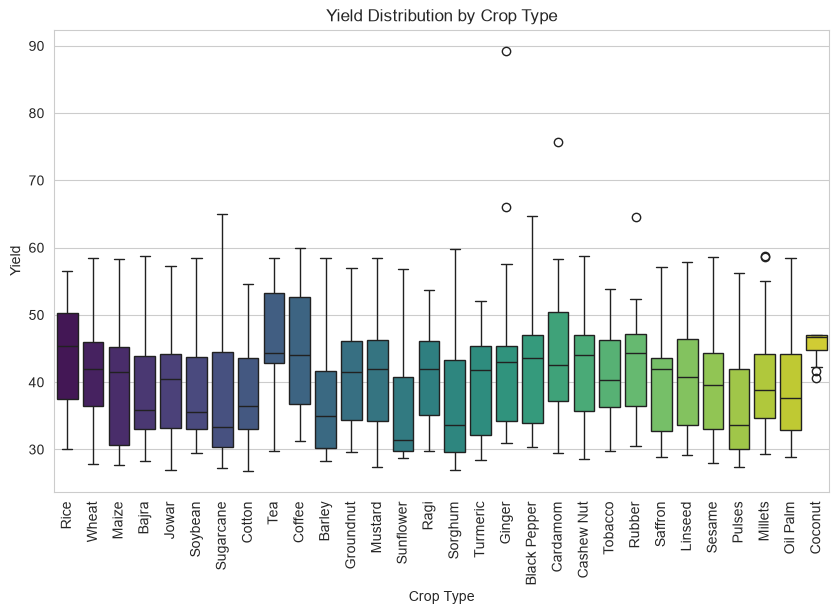

In [56]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=crop_gee, x="crop_type", y="yield", hue= "crop_type", palette="viridis")
plt.xlabel("Crop Type")
plt.ylabel("Yield")
plt.title("Yield Distribution by Crop Type")
plt.xticks(rotation=90)
plt.show()

In [57]:
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

Outliers detected in yield: 3
Outliers detected in gee_ndvi: 75
Outliers detected in gee_gndvi: 117
Outliers detected in gee_ndwi: 117
Outliers detected in gee_savi: 9
Outliers detected in soil_moisture: 89
Outliers detected in gee_temp: 89
Outliers detected in gee_rainfall: 160


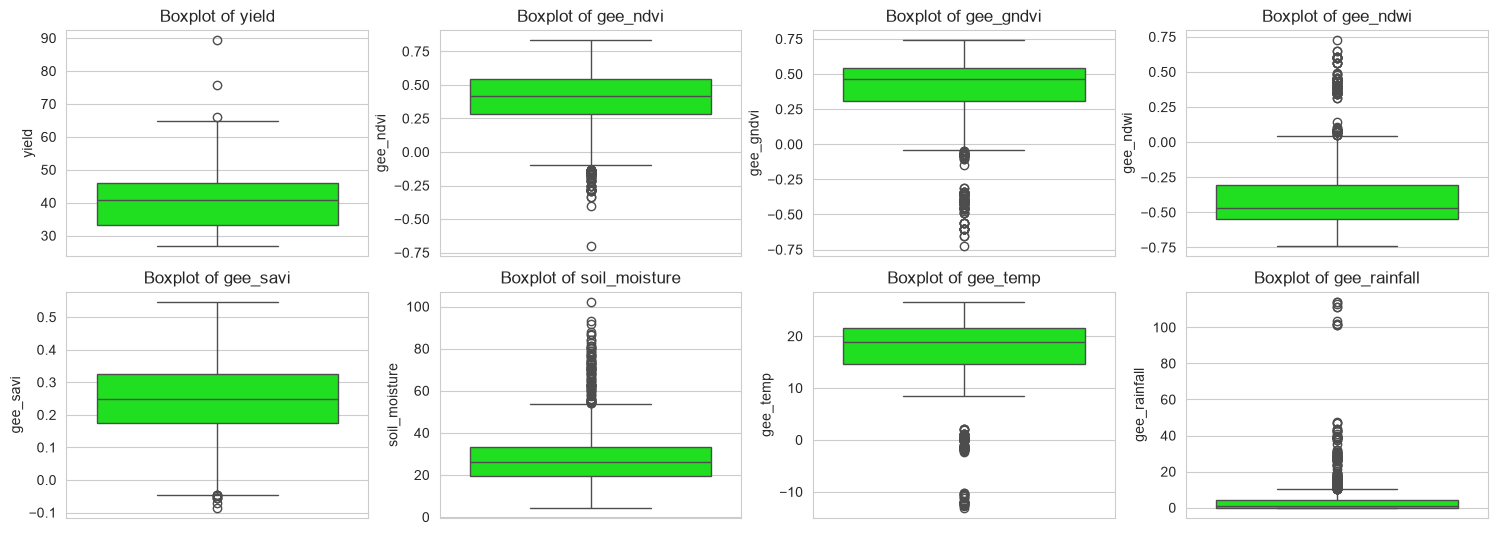

In [58]:
plt.figure(figsize=(15,8))

for i,col in enumerate (["yield", "gee_ndvi", "gee_gndvi", "gee_ndwi", "gee_savi", "soil_moisture", "gee_temp", "gee_rainfall"]):
    
    outliers = detect_outliers(crop_gee, col)
    print(f"Outliers detected in {col}: {len(outliers)}")
    
    plt.subplot(3,4,i+1)    
    sns.boxplot(y=crop_gee[col],color='lime')
    plt.title(f"Boxplot of {col}")
    plt.xlabel('')
    plt.ylabel(col)    

plt.tight_layout()
plt.show()

In [59]:
# Handle Outliers
# IQR Method to identify and cap Outliers
def cap_outliers(data,column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)


for col in ["yield", "gee_ndvi", "gee_gndvi", "gee_ndwi", "gee_savi", "soil_moisture", "gee_temp", "gee_rainfall"]:
    cap_outliers(crop_gee, col) 

Outliers detected in yield: 0
Outliers detected in gee_ndvi: 0
Outliers detected in gee_gndvi: 0
Outliers detected in gee_ndwi: 0
Outliers detected in gee_savi: 0
Outliers detected in soil_moisture: 0
Outliers detected in gee_temp: 0
Outliers detected in gee_rainfall: 0


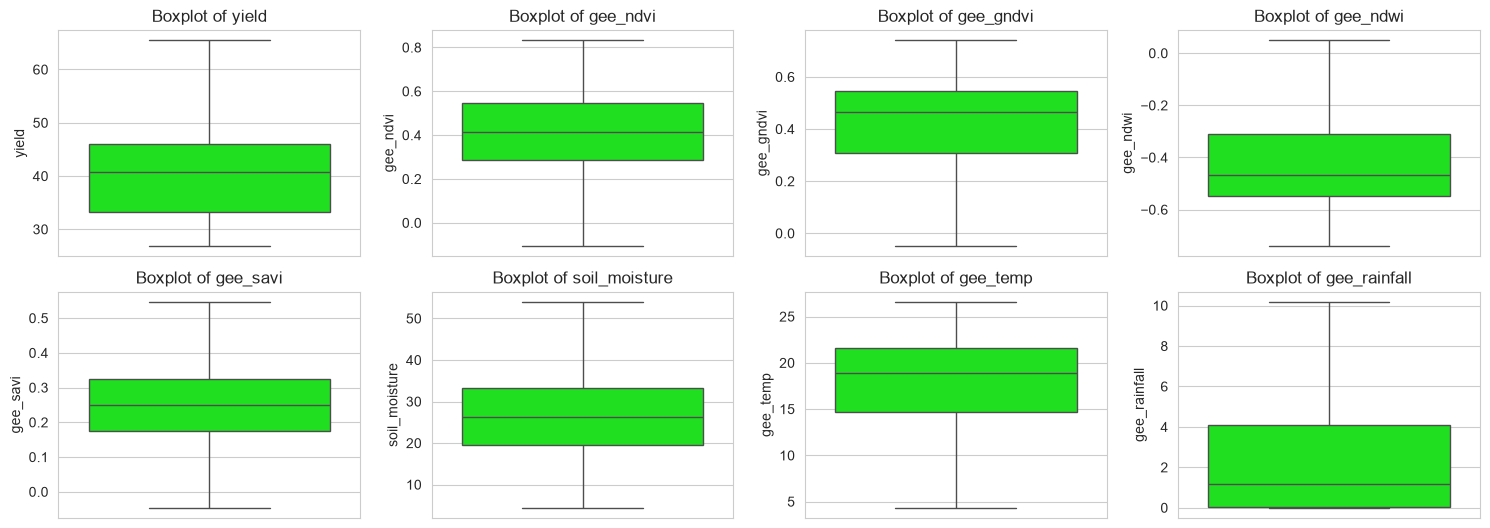

In [60]:
plt.figure(figsize=(15,8))

for i,col in enumerate (["yield", "gee_ndvi", "gee_gndvi", "gee_ndwi", "gee_savi", "soil_moisture", "gee_temp", "gee_rainfall"]):
    
    outliers = detect_outliers(crop_gee, col)
    print(f"Outliers detected in {col}: {len(outliers)}")
    
    plt.subplot(3,4,i+1)    
    sns.boxplot(y=crop_gee[col],color='lime')
    plt.title(f"Boxplot of {col}")
    plt.xlabel('')
    plt.ylabel(col)    

plt.tight_layout()
plt.show()

### Encording categorical data

In [61]:
le = LabelEncoder()
crop_gee["crop_type"] = le.fit_transform(crop_gee["crop_type"])
print(crop_gee.head())

   crop_type  gee_gndvi  gee_ndvi  gee_ndwi  gee_rainfall  gee_savi  \
0         18   0.295214  0.330551 -0.295214      1.261195  0.176135   
1         18   0.426134  0.410556 -0.426134      2.446377  0.197592   
2         18   0.406732  0.399812 -0.406732      3.722453  0.201092   
3         18   0.426134  0.410556 -0.426134      2.314044  0.197592   
4         18   0.426134  0.410556 -0.426134      1.325544  0.197592   

    gee_temp  soil_moisture      yield  
0  19.472947      46.119353  40.218031  
1  19.497637      37.542525  30.870338  
2  21.559492      24.926279  45.330050  
3  19.230342      24.114157  49.711781  
4  18.863504      27.420927  34.542646  


### Scaling the dataset

In [63]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(crop_gee[["crop_type", "gee_gndvi","gee_ndvi","gee_ndwi","gee_rainfall","gee_savi","gee_temp", "soil_moisture"]])
X_scaled = pd.DataFrame(scaled_features, columns= ["crop_type", "gee_gndvi","gee_ndvi","gee_ndwi","gee_rainfall","gee_savi","gee_temp", "soil_moisture"])
y = crop_gee["yield"]

In [64]:
yield_feature_names = X_scaled.columns.tolist()
print(yield_feature_names)

['crop_type', 'gee_gndvi', 'gee_ndvi', 'gee_ndwi', 'gee_rainfall', 'gee_savi', 'gee_temp', 'soil_moisture']


### Splitting dataset

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Model Training

In [68]:
model = RandomForestRegressor(random_state=42,n_estimators=500)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [69]:
y_pred = model.predict(X_test)

In [72]:
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.2f}")

R-squared: 0.31


In [73]:
model.score(X_test,y_test)

0.3146700439628538